## Matemática e Estatística Aplicada Para Data Science, Machine Learning e IA
## Projeto 7
### Respondendo Perguntas de Negócio com Distribuições de Probabilidade de Variáveis Contínuas

In [1]:
# Imports
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
from scipy.stats import expon
from scipy.stats import norm
from scipy.integrate import quad

## O Que São Variáveis Aleatórias Contínuas?

Leia o ebook no Capítulo 20 com a definição.

## O Que é e Para que Serve a Função de Densidade?

A função de densidade de probabilidade (FDP), também conhecida simplesmente como função de densidade, é um conceito fundamental na teoria da probabilidade, especialmente no estudo de variáveis aleatórias contínuas. Ela serve como base para a definição de conceitos importantes como valor esperado, variância e mediana de uma distribuição, além de ser utilizada para realizar inferências estatísticas e construir modelos probabilísticos.

Ela descreve como as probabilidades são distribuídas ao longo de um intervalo de valores possíveis que uma variável aleatória contínua pode assumir. Em outras palavras: A função de densidade fornece uma maneira de calcular a probabilidade de que uma variável aleatória caia dentro de um determinado intervalo.

Exemplo: Uma variável aleatória contínua chamada altura pode assumir qualquer valor dentro de um intervalo!

- Altura: 1,75
- Altura: 1,751
- Altura: 1,7512....

A probabilidade de que a variável aleatória X esteja entre dois valores a e b é dada pela área sob a curva da função de densidade entre a e b. Matematicamente, isso é expresso como:

![DSA](img_graphics/dsa_formula_1.png)

A FDP, denotada geralmente por f(x), é tal que a probabilidade da variável aleatória contínua X cair dentro de um intervalo específico é dada pelo integral da FDP nesse intervalo. 

A função de densidade de probabilidade tem duas propriedades importantes:

**Não-negatividade**: f(x)≥0 para todo x.

**Normalização**: O integral da FDP sobre todo o espaço possível da variável é igual a 1, simbolizando a certeza de que a variável aleatória assumirá algum valor dentro desse espaço:

![DSA](img_graphics/dsa_formula_2.png)

## Conceito de Integral

A integral é um conceito fundamental no cálculo, representando o processo de agregar ou somar partes para determinar o todo. Existem dois tipos principais de integrais: a integral definida e a integral indefinida (ou antiderivada).

Cálculo Integral é o ramo do cálculo onde estudamos integrais e suas propriedades. Integração é um conceito é o processo inverso de diferenciação (cálculo da derivada estudado nos capítulos anteriores). Tanto o cálculo integral quanto o diferencial estão relacionados entre si pelo teorema fundamental do cálculo.

Se conhecermos f’ de uma função que é derivável em seu domínio, poderemos então calcular f. No cálculo diferencial, costumamos chamar f’, a derivada da função f. 

No cálculo integral, chamamos f de antiderivada ou primitiva da função f’. E o processo de encontrar as antiderivadas é conhecido como antidiferenciação ou integração. Como o nome sugere, é o inverso de encontrar diferenciação.

**Integral Indefinida**

A integral indefinida de uma função f(x) é outra função F(x) cuja derivada é f(x). Em outras palavras, se você derivar F(x), obterá f(x). Isso é expresso como:

![DSA](img_graphics/dsa_formula_3.png)

onde C é a constante de integração, refletindo o fato de que existem infinitas antiderivadas para f(x), diferindo apenas por uma constante.

**Integral Definida**

A integral definida é usada para calcular a área sob a curva de uma função f(x) entre dois pontos no eixo x, chamados limites de integração. Se a e b são esses limites, a integral definida é representada como:

![DSA](img_graphics/dsa_formula_4.png)

O valor da integral definida representa a área líquida sob a curva f(x) de a a b, considerando áreas acima do eixo x como positivas e áreas abaixo como negativas.

O dx na fórmula representa um elemento infinitesimal de comprimento ao longo do eixo x. Em termos mais simples, você pode pensar em dx como um pedaço muito pequeno, quase zero, do eixo x.

Quando você calcula a integral de uma função f(x) de a a b, está somando todos os valores de f(x) multiplicados por esses pequenos pedaços dx ao longo do intervalo de a a b. 

Essa soma infinita de produtos f(x)dx dá a área total sob a curva de f(x) entre a e b, como veremos no gráfico a seguir.

## Para Que Serve a Integral?

Leia o ebook no Capítulo 20 com a definição.

## Demonstração Prática do Uso de Integral na Distribuição de Probabilidade 

Aqui está o gráfico que demonstra o uso da integral para calcular a área sob a curva da distribuição de probabilidade normal entre os valores -1 e 1. Esta área corresponde à probabilidade de uma variável aleatória normal padrão cair nesse intervalo, o que, no caso de uma distribuição normal padrão, é aproximadamente 68%.

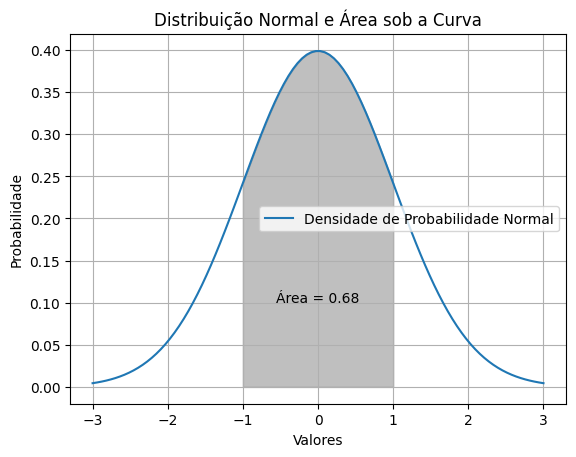

In [2]:
# Definindo os parâmetros para uma distribuição normal
mu, sigma = 0, 1
x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 100)

# Criando a função para a densidade de probabilidade normal
def normal_dstribution_function(x):
   value = norm.pdf(x, mu, sigma)
   return value

# Definindo o intervalo para o cálculo da área sob a curva
a, b = -1, 1

# Calculando a integral da distribuição normal no intervalo [a, b]
integral, _ = quad(normal_dstribution_function, a, b)

# Plotando a função de densidade de probabilidade
plt.plot(x, norm.pdf(x, mu, sigma), label='Densidade de Probabilidade Normal')

# Preenchendo a área sob a curva no intervalo [a, b]
px = np.linspace(a, b, 100)
py = norm.pdf(px, mu, sigma)
plt.fill_between(px, py, color='grey', alpha=0.5)

# Adicionando anotações no gráfico
plt.text(0, 0.1, f'Área = {integral:.2f}', horizontalalignment='center')
plt.title('Distribuição Normal e Área sob a Curva')
plt.xlabel('Valores')
plt.ylabel('Probabilidade')
plt.legend()
plt.grid(True)
plt.show()

## Distribuições de Probabilidade Contínuas Comuns

As distribuições de probabilidade contínuas são modelos matemáticos que descrevem como os valores de uma variável contínua são distribuídos em um determinado intervalo. Algumas das distribuições contínuas mais comuns incluem:

**Distribuição Uniforme**: Nesta distribuição, todos os valores dentro de um intervalo específico têm a mesma probabilidade de ocorrer. É útil para modelar fenômenos onde não há preferência por valores específicos dentro do intervalo.

**Distribuição Exponencial**: Descreve o tempo entre eventos em um processo de Poisson, ou seja, eventos que ocorrem independentemente com uma taxa constante.

**Distribuição Normal (Gaussiana)**: É talvez a mais conhecida, caracterizada por sua curva em forma de sino e descrita por dois parâmetros: a média (μ) e o desvio padrão (σ). É utilizada em uma vasta gama de fenômenos naturais, sociais e econômicos e, claro, em Machine Learning.

As distribuições de probabilidade contínuas são fundamentais para a modelagem de fenômenos em diversas áreas, como física, engenharia, economia e ciências sociais, fornecendo uma ferramenta essencial para o entendimento e a previsão de comportamentos e resultados variados.

## Distribuição Uniforme Contínua

Para ilustrar a distribuição uniforme contínua, vamos considerar um cenário em que uma empresa produz peças com comprimentos que variam de forma uniforme entre 5.2 e 15.7 centímetros. Isso significa que qualquer comprimento dentro desse intervalo é igualmente provável de ser produzido. A distribuição uniforme é caracterizada por essa igualdade de probabilidades para todos os valores dentro de um determinado intervalo.

Na distribuição uniforme contínua, a função de densidade de probabilidade (FDP) é constante entre os limites inferior e superior do intervalo de valores possíveis, e zero fora deste intervalo. A altura da FDP é 1/(b−a), onde 
a e b são, respectivamente, os limites inferior e superior do intervalo. Neste exemplo, a = 5.2 e b = 15.7.

Vamos calcular a FDP para esse intervalo e criar um gráfico para visualizar a distribuição uniforme contínua dos comprimentos das peças.

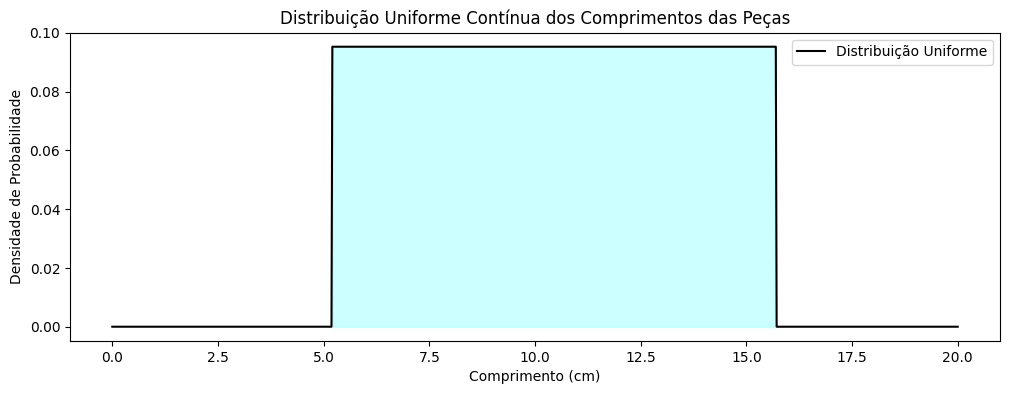

In [3]:
# Limites da distribuição uniforme
a = 5.2 # limite inferior
b = 15.7 # limite superior
largura = b - a

# Valores para o eixo x
x_uniforme = np.linspace(0, 20, 1000)

# Calculando a FDP para os valores x
y_uniforme = uniform.pdf(x_uniforme, loc=a, scale=largura)

# Criando o plot
plt.figure(figsize=(12, 4))
plt.plot(x_uniforme, y_uniforme, label='Distribuição Uniforme', color='black')

# Preenche o interior do gráfico
plt.fill_between(x_uniforme, y_uniforme, where=(x_uniforme >=a) & (x_uniforme <= b), color='cyan', alpha=0.2)

plt.title('Distribuição Uniforme Contínua dos Comprimentos das Peças')
plt.xlabel('Comprimento (cm)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

In [4]:
# Probabilidades
print(y_uniforme)

[0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.       

O gráfico mostra a distribuição uniforme contínua dos comprimentos das peças fabricadas, variando de 5.2 a 15.7 centímetros. 

Como esperado em uma distribuição uniforme, a função de densidade de probabilidade (FDP) é constante dentro deste intervalo, indicando que todos os comprimentos dentro do intervalo têm a mesma probabilidade de ocorrência. Fora desse intervalo, a probabilidade é zero, como representado pelas partes do gráfico onde a linha da FDP toca o eixo x. 

A função de densidade de probabilidade (FDP) para uma distribuição uniforme contínua é dada por: f(x) = 1/(b−a), para a ≤ x ≤ b, e zero fora desse intervalo. 

Em nosso caso, seria: f(x) = 1 / (b−a) = 1 / (15.7 - 5.2) = 1 / 10.5 = 0.0952381 x 100 = 9.5%

**E se quisermos calcular a probabilidade de produzir uma peça de 6.5 cm especificamente?**

Na distribuição uniforme contínua, a probabilidade de obter um valor específico é tecnicamente zero, pois há infinitos valores possíveis dentro do intervalo. No entanto, podemos calcular a probabilidade de obter um valor dentro de um intervalo muito pequeno em torno do valor desejado.

Para este exemplo, vamos calcular a probabilidade de produzir uma peça com comprimento entre 6.499 e 6.501 centímetros (ou seja, um intervalo de 0.002 centímetros em torno de 6.5 cm). Essa abordagem é uma aproximação para a probabilidade de obter um valor "próximo" a 6.5 cm.

A função de densidade de probabilidade (FDP) para uma distribuição uniforme contínua é dada por: f(x) = 1/(b−a)

In [5]:
# Parâmetros do intervalo
a = 5.2
b = 15.7

# Largura do intervalo que desejamos calcular
largura_intervalo = 0.002

# Calcula a FDP
fdp = 1 / (b - a)

# Calcula a probabilidade
probabilidade = fdp * largura_intervalo * 100

print(f"A probabilidade de produzir uma peça de 6.5 cm é de: {probabilidade}")

A probabilidade de produzir uma peça de 6.5 cm é de: 0.01904761904761905


## Distribuição Exponencial

Vamos considerar um exemplo da distribuição exponencial relacionado ao tempo de resposta da equipe de TI aos incidentes relacionados aos sistemas de uma empresa. Em serviços de TI ou em operações de emergência, onde a resposta rápida é crucial, a distribuição exponencial pode modelar o tempo até a resposta ao próximo incidente crítico, ajudando a melhorar a eficiência da equipe de resposta.

Suponha que a taxa média de incidentes seja de 3 incidentes por hora. A distribuição exponencial é frequentemente usada para modelar o tempo entre eventos em um processo de Poisson, como neste caso.

O processo de Poisson é um modelo matemático utilizado para descrever fenômenos que ocorrem aleatoriamente no tempo ou no espaço de forma independente e a uma taxa média constante. É amplamente aplicado em diversas áreas, como física, telecomunicações, finanças e seguros, para modelar a ocorrência de eventos dentro de intervalos de tempo fixos ou regiões espaciais definidas. 

A Densidade de Probabilidade em uma distribuição exponencial representa a probabilidade de um evento ocorrer em um pequeno intervalo de tempo, dada que a distribuição descreve o tempo entre eventos em um processo de Poisson. **Como a função é contínua, ela dá a probabilidade por unidade de tempo e não uma probabilidade exata para um ponto específico no tempo.**

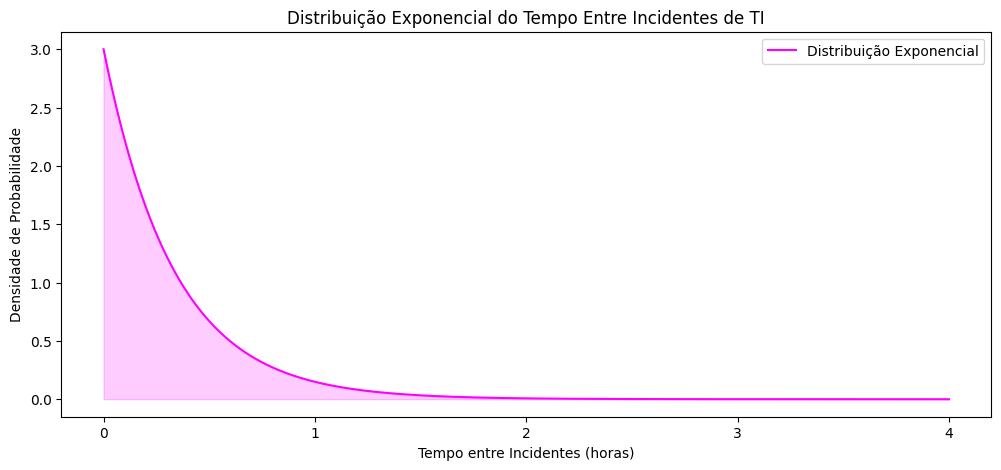

In [6]:
# Parâmetros lambda da distribuição exponencial
lambda_param = 3

# Calculando o tempo médio entre os incidentes
tempo_medio_entre_incidentes = 1 / lambda_param

# Valores para o eixo x
x_exponencial = np.linspace(0, 4, 1000)

# Calculando a FDP (Função Densidade de Probabilidade) para os valores x
y_exponencial = expon.pdf(x_exponencial, scale=tempo_medio_entre_incidentes)

# Criando o plot
plt.figure(figsize=(12, 5))
plt.plot(x_exponencial, y_exponencial, label='Distribuição Exponencial', color='magenta')

# Preeenchendo a área sob a curva para representar a variável contínua
plt.fill_between(x_exponencial, y_exponencial, alpha=0.2, color='magenta')

# Definindo as marcações do eixo x para serem valores inteiros de 0 e 4
plt.xticks(np.arange(0, 5, 1))

# Labels
plt.title('Distribuição Exponencial do Tempo Entre Incidentes de TI')
plt.xlabel('Tempo entre Incidentes (horas)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

A distribuição exponencial é uma distribuição que modela o tempo entre eventos em um processo de Poisson, onde os eventos ocorrem de forma contínua e independente a uma taxa constante. Uma característica chave da distribuição exponencial é que ela é uma distribuição "sem memória", o que significa que a probabilidade de um evento ocorrer em um determinado intervalo de tempo é a mesma, independentemente de quanto tempo já passou.

A razão pela qual a PDF é maior entre 0 e 1 e menor entre 1 e 4 neste caso está relacionada ao fato de que a distribuição exponencial é decrescente. Isso significa que valores menores de x (tempo entre incidentes) são mais prováveis do que valores maiores. Em outras palavras, é mais provável que ocorram tempos menores entre incidentes do que tempos maiores.

Para interpretar este gráfico, observe os seguintes pontos:

**Decaimento Exponencial**: A curva mostra um decaimento exponencial, indicando que a probabilidade de um incidente ocorrer diminui à medida que o tempo aumenta. Quanto maior o intervalo de tempo entre os incidentes, menos provável é que um novo incidente ocorra nesse intervalo.

**Taxa de Incidentes (λ)**: O parâmetro λ é de 3, o que sugere que, em média, espera-se que 3 incidentes ocorram por unidade de tempo. Se a unidade de tempo for, por exemplo, uma hora, então em média esperamos que 3 incidentes ocorrarm a cada hora.

**Tempo Médio entre Incidentes**: O tempo médio entre as chegadas, que é o inverso de λ (1/λ), é de aproximadamente 0.29 horas (ou cerca de 17.4 minutos). Isso significa que, em média, espera-se que um novo incidente chegue a cada 17.4 minutos.

**Área sob a Curva**: A área total sob a curva de uma função de densidade de probabilidade é sempre igual a 1, que representa a probabilidade certa de que um evento ocorra. A área sombreada sob a curva até um certo ponto x representa a probabilidade acumulada de um incidente ocorrer dentro desse intervalo de tempo.

**Uso Prático**: No contexto de negócios, essa informação pode ser usada para planejamento de pessoal, para garantir que haja atendimento suficiente para os incidentes esperados, para gerenciar estoque em função da demanda prevista ou para planejar a capacidade de atendimento em serviços como saúde, logística, etc.

Portanto, este gráfico é uma ferramenta útil para visualizar e compreender a natureza do processo pelo qual os incidentes (ou eventos) ocorrem e como eles estão distribuídos ao longo do tempo, permitindo a tomada de decisões baseadas em dados para a gestão eficiente dos recursos.

Nota: A distribuição de Poisson (discreta) trata do número de ocorrências em um período fixo de tempo e a distribuição exponencial (contínua) trata do tempo entre ocorrências de eventos sucessivos à medida que o tempo passa continuamente. 

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->

Qual a probabilidade de ocorrer pelo menos um incidente na próxima hora? Acompanhe a solução no videobook a seguir.

In [7]:
# Calculando a probabilidade de pelo menos um incidente na próxima hora
# Que é o complemento da probabilidade de nenhum incidente (CDF em x=1)
probabilidade_pelo_menos_um_incidente = 1 - expon.cdf(1, scale=tempo_medio_entre_incidentes)

In [8]:
prob_final = probabilidade_pelo_menos_um_incidente * 100

In [9]:
print(f"A probabilidade de pelo menos 1 incidente na próxima hora (próxima unidade de tempo) é de: {prob_final}")

A probabilidade de pelo menos 1 incidente na próxima hora (próxima unidade de tempo) é de: 4.978706836786396


## Distribuição Normal

A distribuição normal, também conhecida como distribuição gaussiana, é uma distribuição de probabilidade simétrica em relação à média, mostrando que dados próximos à média têm ocorrência mais frequente do que dados distantes da média. A distribuição normal aparece como uma "curva em sino" quando representada graficamente.

Em uma distribuição normal, a média é zero e o desvio padrão é 1. Possui distorção zero e curtose de 3.

As distribuições normais são simétricas, mas nem todas as distribuições simétricas são normais.

Observe os fenômenos a sua volta. Muitos podem ser explicados com uma Distribuição Normal.

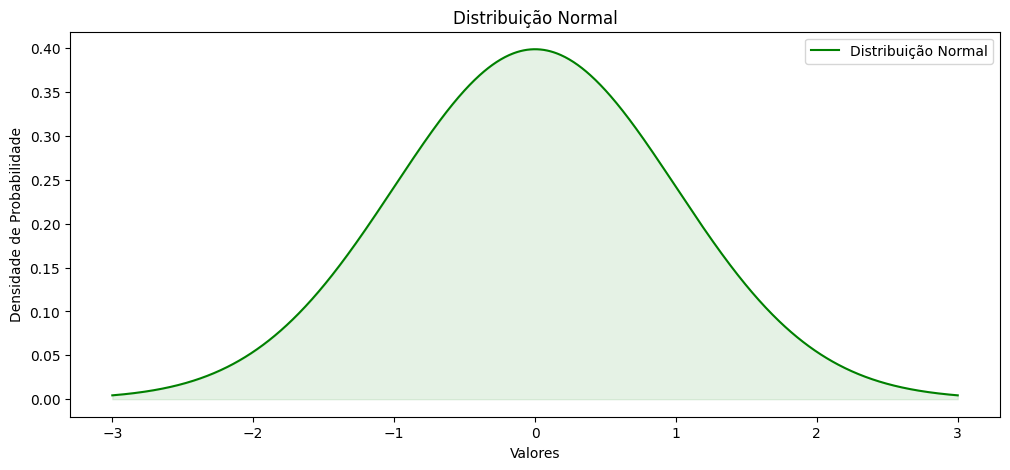

In [10]:
# Definindo os parâmetros para uma distribuição normal padrão
mu = 0 # média
sigma = 1 # desvio padrão

# Gerando valores para o eixo x
x_normal = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 1000)

# Calculando a FDP (Função Densidade de Probabilidade) para valores x
y_normal = norm.pdf(x_normal, mu, sigma)

# Criando o plot
plt.figure(figsize=(12, 5))
plt.plot(x_normal, y_normal, label='Distribuição Normal', color='green')

# Preenchendo a área sob a curva para representa a variável contínua
plt.fill_between(x_normal, y_normal, alpha=0.1, color='green')

plt.title('Distribuição Normal')
plt.xlabel('Valores')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

A distribuição normal padrão possui dois parâmetros: a média e o desvio padrão. Em uma distribuição normal, média (média), mediana (ponto médio) e moda (observação mais frequente) são iguais. Esses valores representam o pico ou ponto mais alto. A distribuição cai então simetricamente em torno da média, cuja largura é definida pelo desvio padrão.

O modelo de distribuição normal é fundamental para o Teorema Central do Limite, que afirma que as médias calculadas a partir de variáveis aleatórias independentes e distribuídas de forma idêntica têm distribuições aproximadamente normais, independentemente do tipo de distribuição da qual as variáveis são amostradas.

Para todas as distribuições normais, 68,2% das observações aparecerão dentro de mais ou menos um desvio padrão da média; 95,4% ficarão dentro de +/- dois desvios padrão; e 99,7% dentro de +/- três desvios padrão.

Esse fato é chamado de “regra empírica”, uma heurística que descreve onde aparecerá a maioria dos dados em uma distribuição normal. Dados fora dos três desvios padrão ("3-sigma") significariam ocorrências raras (outliers).

**Assimetria (Skewness)**

A assimetria mede o grau de simetria de uma distribuição. A distribuição normal é simétrica e tem assimetria zero. Se a distribuição de um conjunto de dados tiver uma assimetria menor que zero, ou assimetria negativa (assimetria à esquerda), então a cauda esquerda da distribuição é mais longa que a cauda direita; a assimetria positiva (assimetria à direita) implica que a cauda direita da distribuição é mais longa que a esquerda.

**Curtose (Kurtosis)**

A curtose mede a espessura das extremidades finais de uma distribuição até as caudas de uma distribuição. A distribuição normal tem curtose igual a 3,0. Distribuições com curtose maior que 3,0 exibem dados de cauda excedendo as caudas da distribuição normal (por exemplo, cinco ou mais desvios padrão da média).

Esse excesso de curtose é conhecido nas estatísticas como leptocúrtico. Distribuições com baixa curtose inferior a 3,0 (platicúrtica) exibem caudas que são geralmente menos extremas ("mais magras") do que as caudas da distribuição normal.

## Distribuição Normal - Cenário 1

Vamos considerar um cenário de negócios onde uma empresa fabrica lâmpadas LED. A vida útil dessas lâmpadas segue uma distribuição normal com média de 10.000 horas e desvio padrão de 1.200 horas. A empresa deseja saber a probabilidade de uma lâmpada escolhida aleatoriamente durar mais de 12.000 horas, para poder fornecer uma garantia baseada nesta informação.

Para responder a essa pergunta, podemos usar a distribuição normal e calcular a área sob a curva da função de densidade de probabilidade (FDP) para valores superiores a 12.000 horas. Em Python, isso pode ser feito usando a biblioteca scipy, mais especificamente a função norm.sf (survival function), que é o complemento da função de distribuição cumulativa e nos dá a probabilidade de uma variável aleatória sob a distribuição normal ser maior que um certo valor.

In [11]:
# Parâmetros da distribuição normal
media = 10000 # média da vida útil das lâmpadas em horas
desvio_padrao = 1200 # desvio padrão da vida últil em horas

# Calculando a probabilidade de uma lâmpada durar mais de 12.000 horas
probabilidade = norm.sf(12000, loc=media, scale=desvio_padrao)

print(f"\nProbabilidade: {probabilidade * 100}")


Probabilidade: 4.7790352272814705


A probabilidade de uma lâmpada LED escolhida aleatoriamente durar mais de 12.000 horas é aproximadamente 4,78%. Com base nessa informação, a empresa pode decidir como estruturar sua garantia, levando em conta que uma pequena porcentagem das lâmpadas excederá esse limite de duração. 

Vamos criar a FDP e plotar a distribuição de probabilidade.

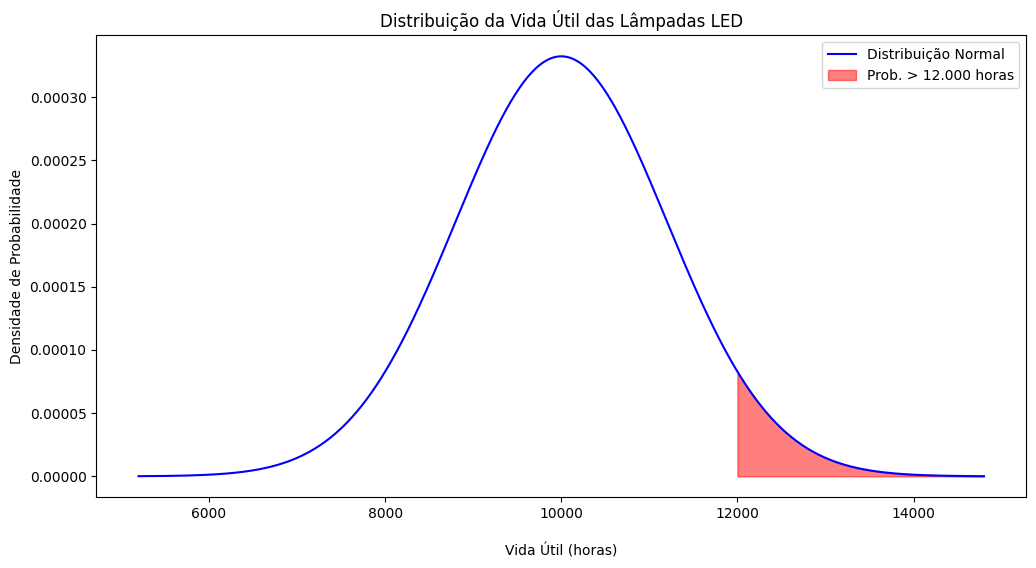

In [12]:
# Definindo os valores para o eixo x (vida útil da lâmpada)
x = np.linspace(media - 4 * desvio_padrao, media + 4 * desvio_padrao, 1000)

# Calculando a função a densidade de probabilidade para os valores x
y = norm.pdf(x, loc=media, scale=desvio_padrao)

# Criando o plot
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Distribuição Normal', color='blue')

# Área representando a probabilidad de vida útil > 12.000 horas
x_shade = np.linspace(12000, media + 4 * desvio_padrao, 1000)
y_shade = norm.pdf(x_shade, loc=media, scale=desvio_padrao)
plt.fill_between(x_shade, y_shade, color='red', alpha=0.5, label='Prob. > 12.000 horas')

plt.title('Distribuição da Vida Útil das Lâmpadas LED')
plt.xlabel('\nVida Útil (horas)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

O gráfico ilustra a distribuição normal da vida útil das lâmpadas LED, com a área em vermelho destacando a probabilidade de uma lâmpada durar mais de 12.000 horas. Como observado, esta área representa uma pequena fração da distribuição total, o que está alinhado com a probabilidade calculada de aproximadamente 4,78%. Este visual ajuda a entender graficamente como a vida útil esperada se distribui e onde se situam os valores de interesse específicos para decisões de negócios, como a definição de termos de garantia. 

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->

## Distribuição Normal - Cenário 2

Vamos criar um exemplo onde estamos interessados em saber a probabilidade de uma lâmpada LED, produzida pela mesma empresa, durar entre 9.000 e 11.000 horas, um intervalo que cai mais próximo do centro da distribuição.

Para encontrar essa probabilidade, podemos utilizar a função de distribuição cumulativa (CDF) da distribuição normal. A CDF nos dá a probabilidade de uma variável aleatória sob a distribuição normal ser menor ou igual a um certo valor. Assim, para calcular a probabilidade de a vida útil da lâmpada estar entre 9.000 e 11.000 horas, calcularemos a diferença entre a probabilidade da variável ser menor ou igual a 11.000 horas e a probabilidade de ser menor ou igual a 9.000 horas.

Vamos calcular e depois plotar a distribuição, destacando o intervalo de interesse.

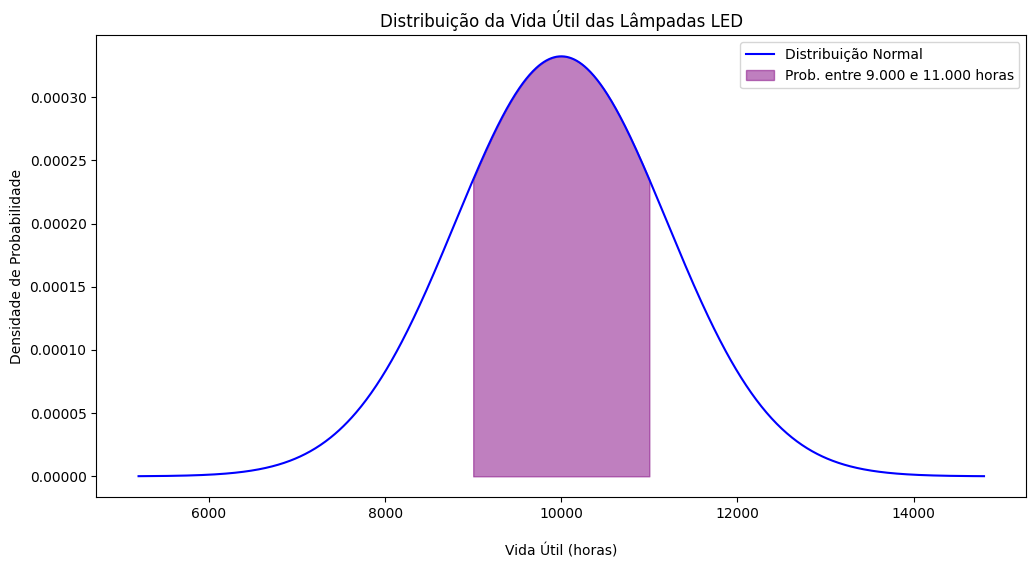


Probabilidade: 59.53432380727137


In [13]:
# Calculando as probabilidades para os limites inferiore e superior do intervalo
probabilidade_inferior = norm.cdf(9000, loc=media, scale=desvio_padrao)
probabilidade_superior = norm.cdf(11000, loc=media, scale=desvio_padrao)

# Probabilidade da vida útil estar entre 9.000 e 11.000 horas
probabilidade_intervalo = probabilidade_superior - probabilidade_inferior

# Criando o plot
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Distribuição Normal', color='blue')

# Área representando a probabilidade de vida útil entre 9.000 e 11.000 horas
x_shade_centro = np.linspace(9000, 11000, 1000)
y_shade_centro = norm.pdf(x_shade_centro, loc=media, scale=desvio_padrao)
plt.fill_between(x_shade_centro, y_shade_centro, color='purple', alpha=0.5, label='Prob. entre 9.000 e 11.000 horas')

plt.title('Distribuição da Vida Útil das Lâmpadas LED')
plt.xlabel("\nVida Útil (horas)")
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

print(f"\nProbabilidade: {probabilidade_intervalo * 100}")

A probabilidade de uma lâmpada LED durar entre 9.000 e 11.000 horas é aproximadamente 59,53%. O gráfico mostra a distribuição normal da vida útil das lâmpadas, com a área em lilás destacando o intervalo de interesse. 

Esta região está localizada no centro da distribuição, representando uma probabilidade significativa, o que é esperado, considerando que esse intervalo está em torno da média da distribuição (10.000 horas). Este exemplo ilustra como a maior parte da probabilidade se concentra em torno da média em uma distribuição normal, especialmente para intervalos simétricos em relação à média. 

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->

## Distribuição Normal - Cenário 3

Para exemplificar um resultado que caia no lado esquerdo da curva de distribuição normal, vamos considerar a probabilidade de uma lâmpada LED durar menos de 7.500 horas. Este valor está abaixo da média, então esperamos que a probabilidade correspondente esteja localizada no lado esquerdo da distribuição normal.

Para calcular essa probabilidade, podemos usar a função de distribuição cumulativa (CDF) novamente, que nos dá a probabilidade de uma variável aleatória ser menor ou igual a um valor específico. Neste caso, queremos a probabilidade de a variável aleatória (vida útil da lâmpada) ser menor ou igual a 7.500 horas.

Vou calcular essa probabilidade e, em seguida, plotar a distribuição com o intervalo relevante destacado.

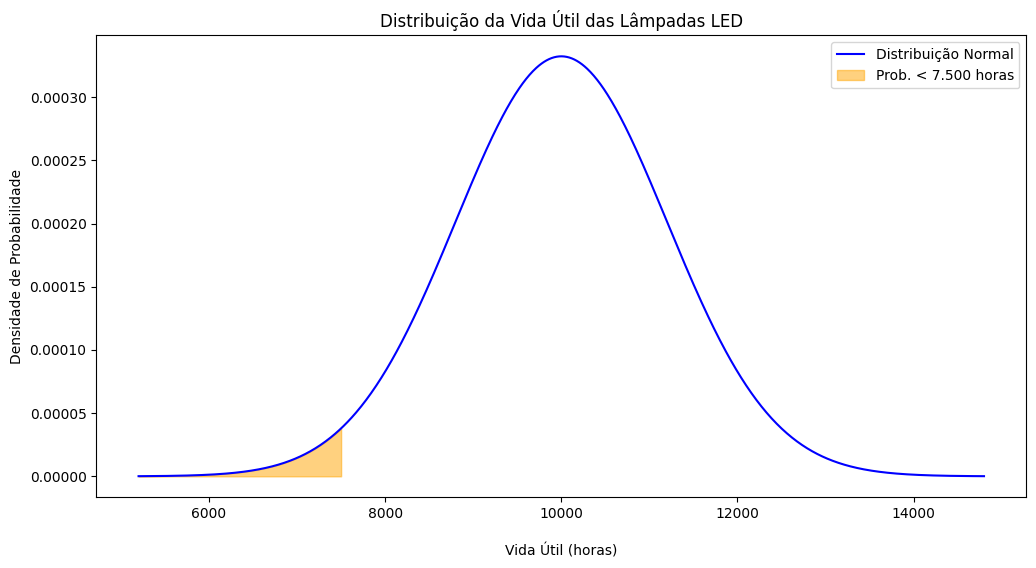


Probabilidade: 1.8610425189886333


In [14]:
# Calculando a probabilidade de uma lâmpada durar menos de 7500 horas
probabilidade_menor_7500 = norm.cdf(7500, loc=media, scale=desvio_padrao)

# Criando o plot
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Distribuição Normal', color='blue')

# Área representando a probabilidade de vida útil < 7.500 horas
x_shade_esquerdo = np.linspace(media - 4 * desvio_padrao, 7500, 1000)
y_shade_esquerdo = norm.pdf(x_shade_esquerdo, loc=media, scale=desvio_padrao)
plt.fill_between(x_shade_esquerdo, y_shade_esquerdo, color='orange', alpha=0.5, label='Prob. < 7.500 horas')

# Labels
plt.title('Distribuição da Vida Útil das Lâmpadas LED')
plt.xlabel('\nVida Útil (horas)')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

print(f"\nProbabilidade: {probabilidade_menor_7500 * 100}")

A probabilidade de uma lâmpada LED durar menos de 7.500 horas é aproximadamente 1,86%. O gráfico ilustra a distribuição da vida útil das lâmpadas LED, com a área em laranja destacando o intervalo à esquerda da média, representando lâmpadas com menor vida útil. Este resultado, localizado no lado esquerdo da curva, reflete uma menor probabilidade, indicando que a maioria das lâmpadas tem uma expectativa de vida maior do que 7.500 horas. 

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
## Distribuição Normal - Regra Empírica

A regra empírica, também conhecida como regra 68-95-99.7, é uma diretriz na estatística que descreve como os dados são distribuídos em muitas distribuições normais (ou gaussianas). Segundo esta regra, para uma distribuição normal:

- Cerca de 68% dos dados estão dentro de um desvio padrão (σ) da média (μ). Isso significa que a maioria dos dados está concentrada ao redor da média, com uma variação relativamente pequena.
- Cerca de 95% dos dados estão dentro de dois desvios padrão (2σ) da média. Isso expande a faixa de dados considerada, incluindo quase todos os valores.
- Cerca de 99.7% (ou praticamente todos) dos dados estão dentro de três desvios padrão (3σ) da média. Essa regra mostra que é muito raro encontrar valores que se afastem mais de três desvios padrão da média na distribuição normal.

Para que Serve a Regra Empírica?

A regra empírica é útil em várias situações, incluindo:

**Avaliação de Normalidade**: Se os dados seguem a regra 68-95-99.7 aproximadamente, isso pode ser um indício de que estão normalmente distribuídos.

**Detecção de Outliers**: Valores que caem fora de três desvios padrão da média são raros em uma distribuição normal e podem ser considerados outliers.

**Planejamento e Previsão**: Em finanças, qualidade de produção e outras áreas, entender a dispersão dos dados ajuda no planejamento e na previsão de eventos futuros.

**Entendimento de Probabilidades**: A regra ajuda a entender as probabilidades associadas a diferentes intervalos de uma distribuição normal, facilitando a interpretação de dados e resultados.

A regra empírica é uma ferramenta poderosa porque a distribuição normal ocorre naturalmente em muitos contextos diferentes, desde medições físicas, como altura e peso, até fenômenos sociais e financeiros. Entretanto, é importante notar que nem todas as distribuições seguem essa regra, então sua aplicabilidade deve ser avaliada caso a caso.

O gráfico abaixo demonstra a aplicação da regra empírica, também conhecida como a regra 68-95-99.7, à distribuição normal da vida útil das lâmpadas LED. Essa regra estabelece que:

- Cerca de 68% dos dados estão dentro de 1 desvio padrão (σ) da média.
- Cerca de 95% dos dados estão dentro de 2 desvios padrão da média.
- Cerca de 99.7% dos dados estão dentro de 3 desvios padrão da média.

Este conceito é fundamental na estatística, pois fornece uma maneira rápida de avaliar a dispersão dos dados em distribuições que são aproximadamente normais, ajudando a entender quão comuns ou raros são certos valores dentro de uma distribuição.

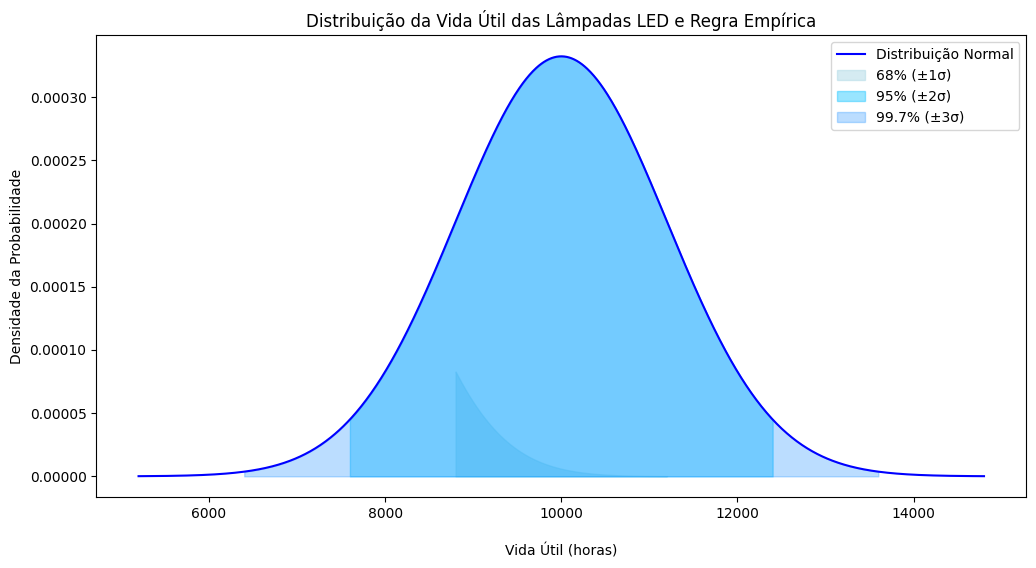

In [15]:
# Calculando os valores para as faixas dentro de 1, 2 e 3 desvios padrão da média
um_desvio = [media - desvio_padrao, media + desvio_padrao]
dois_desvios = [media - 2 * desvio_padrao, media + 2 * desvio_padrao]
tres_desvios = [media - 3 * desvio_padrao, media + 3 * desvio_padrao]

# Criando o plot
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Distribuição Normal', color='blue')

# Área para 1 desvio padrão da média
x_shade_1 = np.linspace(um_desvio[0], um_desvio[1], 1000)
y_shade_1 = norm.pdf(x_shade, loc=media, scale=desvio_padrao)
plt.fill_between(x_shade_1, y_shade_1, color="lightblue", alpha=0.5, label="68% (±1σ)")

# Área para 2 desvios padrão da média
x_shade_2 = np.linspace(dois_desvios[0], dois_desvios[1], 1000)
y_shade_2 = norm.pdf(x_shade_2, loc=media, scale=desvio_padrao)
plt.fill_between(x_shade_2, y_shade_2, color='deepskyblue', alpha=0.4, label='95% (±2σ)')

# Área para 3 desvios padrão da média
x_shade_3 = np.linspace(tres_desvios[0], tres_desvios[1], 1000)
y_shade_3 = norm.pdf(x_shade_3, loc=media, scale=desvio_padrao)
plt.fill_between(x_shade_3, y_shade_3, color='dodgerblue', alpha=0.3, label='99.7% (±3σ)')

# Labels
plt.title('Distribuição da Vida Útil das Lâmpadas LED e Regra Empírica')
plt.xlabel('\nVida Útil (horas)')
plt.ylabel('Densidade da Probabilidade')
plt.legend()
plt.show()
 

In [16]:
# %watermark -v -m

In [17]:
# %watermark --iversions